# Model Interpretation & Explainability
In this notebook, we load previously saved models and perform interpretability analysis using SHAP.

## 1. Load Data & Models

In [2]:
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

print("Loading dataset...")
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

# Clean Sleep Disorder (to match preprocessing)
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
df["Sleep Disorder"] = df["Sleep Disorder"].replace({
    "none": "None",
    "NONE": "None",
    "": "None"
})

drop_cols = ["Person ID", "Blood Pressure"]
target_col = "Quality of Sleep"
feature_cols = [c for c in df.columns if c not in drop_cols + [target_col]]

X = df[feature_cols]
y = df[target_col]

print("Loading trained best model...")
best_model = joblib.load("saved_models/gradient_boosting.joblib")
best_model


Loading dataset...
Loading trained best model...


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Sleep Duration',
                                                   'Physical Activity Level',
                                                   'Stress Level', 'Heart Rate',
                                                   'Daily Steps']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Occupation',
                                                   'BMI Category',
                                                   'Sleep Disorder'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

## 2. Extract Preprocessed Feature Names

In [3]:
# Extract the ColumnTransformer inside the pipeline
preprocessor = best_model.named_steps["preprocess"]
model = best_model.named_steps["model"]

# Get encoded categorical feature names
encoded_cat = list(preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out())

# Combine numeric + encoded categorical names
numeric_features = preprocessor.transformers_[0][2]
all_features = numeric_features + encoded_cat

print("Number of final model features:", len(all_features))

Number of final model features: 26


## 3. Compute SHAP Values

In [4]:
explainer = shap.TreeExplainer(model)

# SHAP requires transformed input (post-preprocessing)
X_transformed = preprocessor.transform(X)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_transformed)

shap_values.shape

Computing SHAP values...


(374, 26)

## 4. SHAP Summary Plot

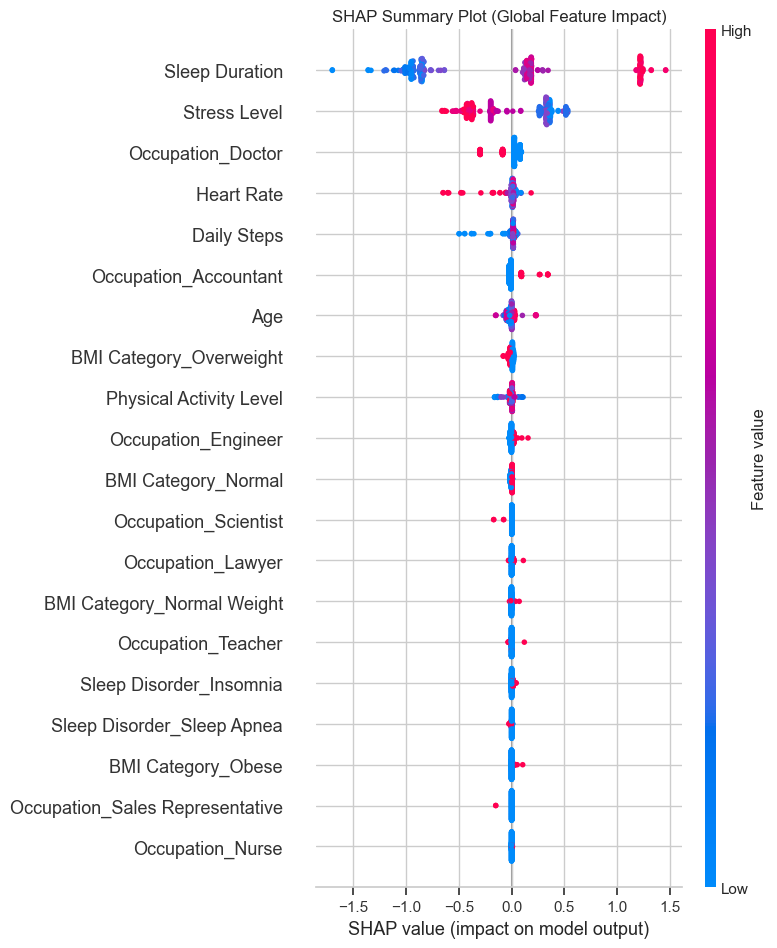

In [5]:
shap.summary_plot(shap_values, X_transformed, feature_names=all_features, show=False)
plt.title("SHAP Summary Plot (Global Feature Impact)")
plt.show()


## 5. SHAP Bar Plot (Ranked Importance)

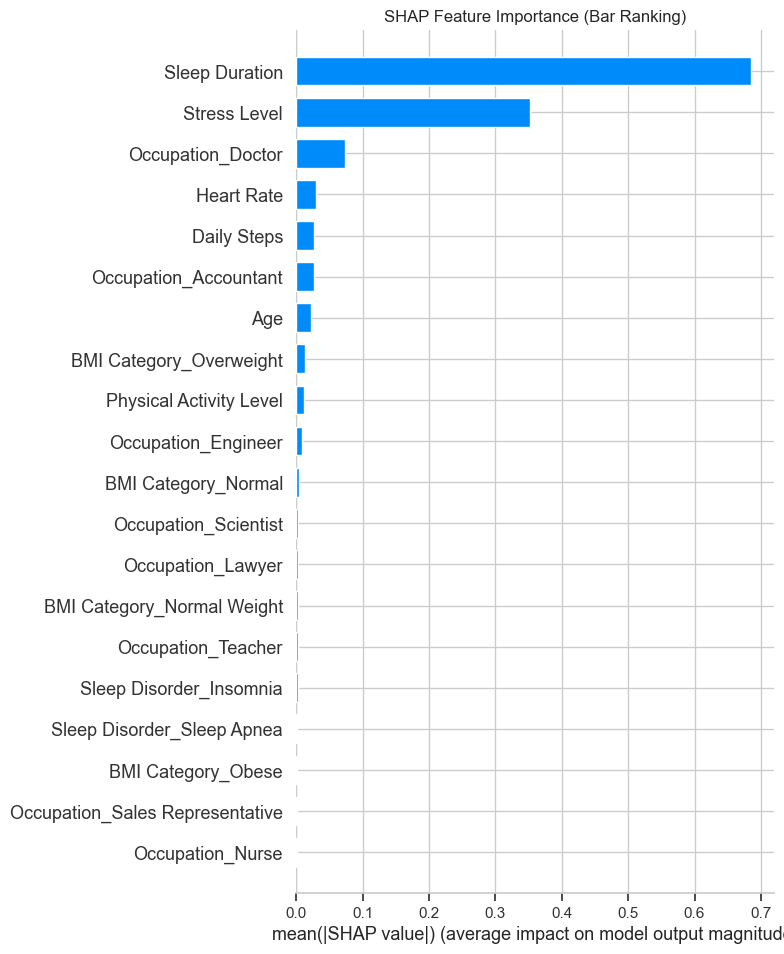

In [6]:

shap.summary_plot(
    shap_values, 
    X_transformed, 
    feature_names=all_features, 
    plot_type="bar", 
    show=False
)
plt.title("SHAP Feature Importance (Bar Ranking)")
plt.show()


## 6. SHAP Dependence Plots

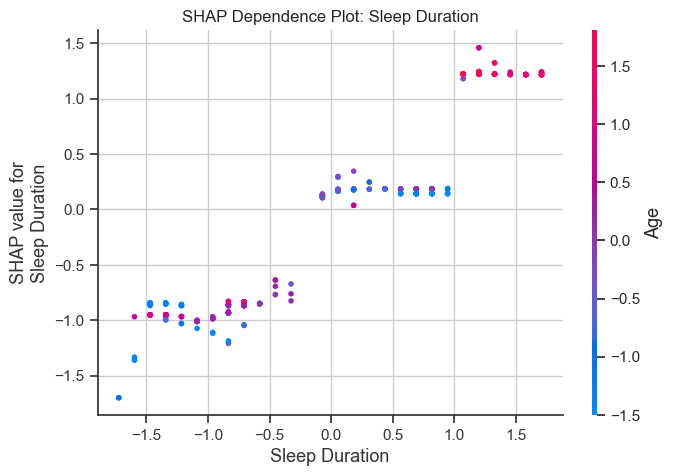

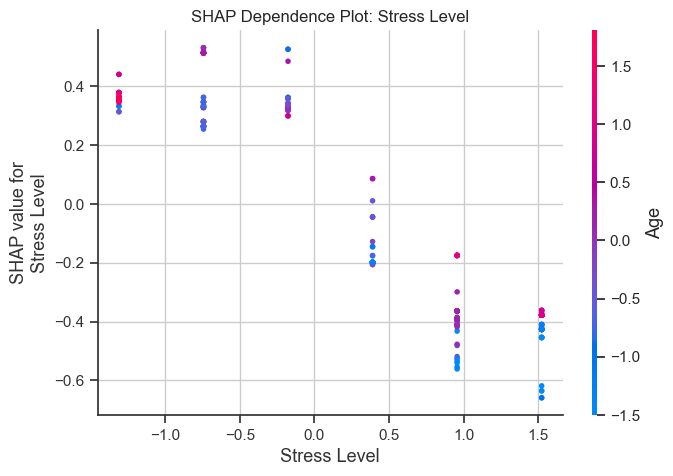

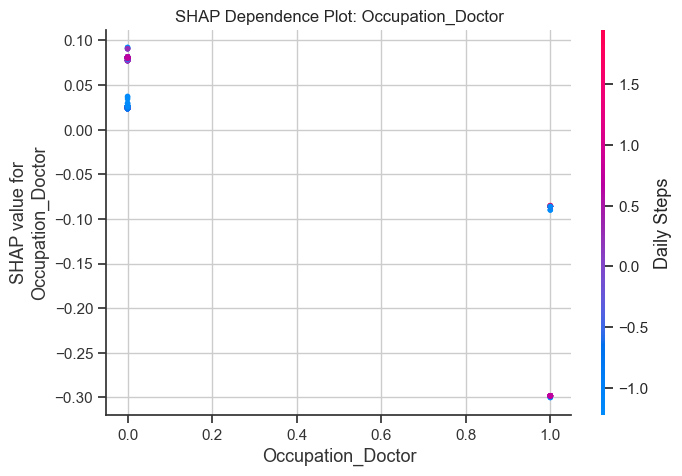

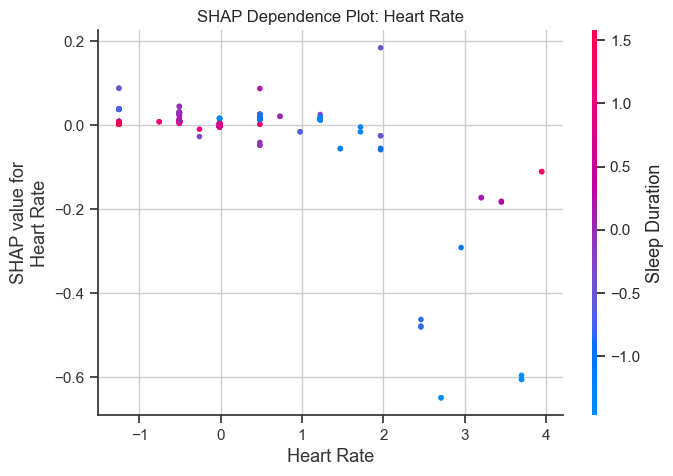

In [8]:
# SHAP mean absolute contributions
importance = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(importance)[::-1][:4]
top_features = [all_features[i] for i in top_idx]

top_features


for feat in top_features:
    shap.dependence_plot(feat, shap_values, X_transformed, feature_names=all_features, show=False)
    plt.title(f"SHAP Dependence Plot: {feat}")
    plt.show()


## Feature Grouping

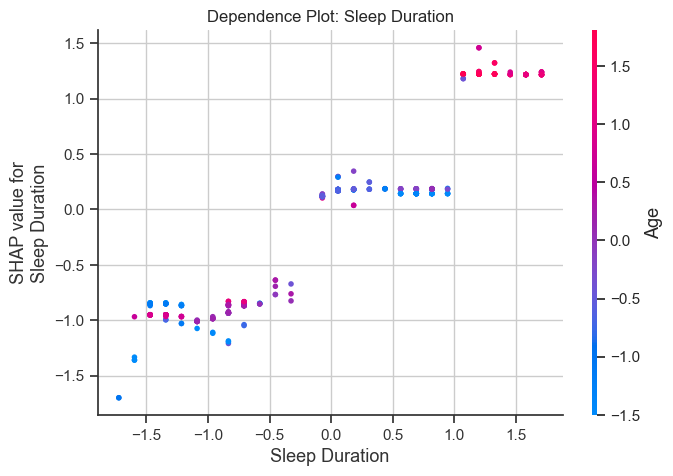

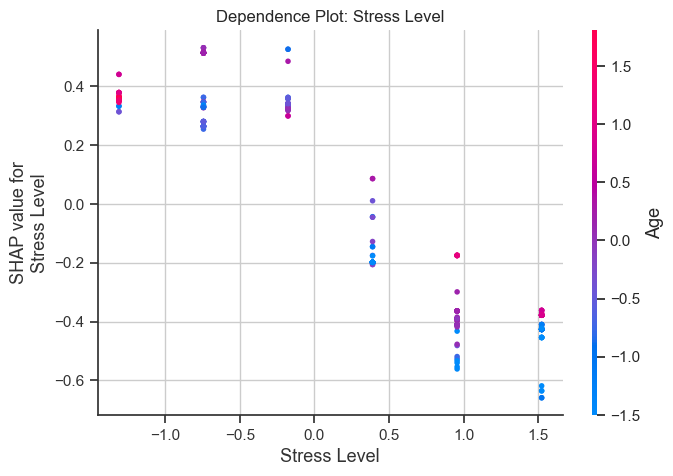

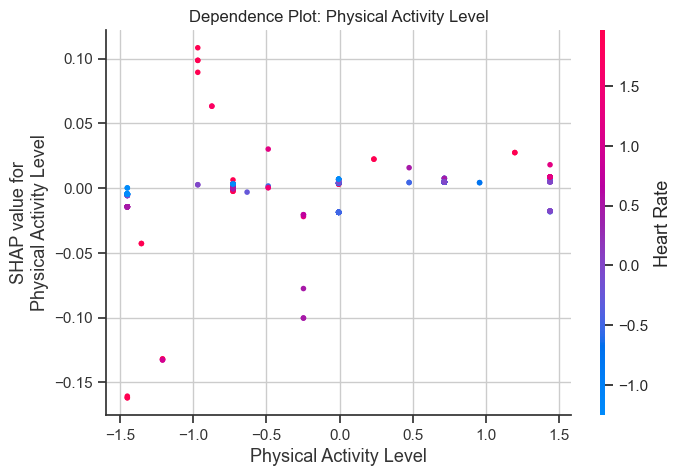

In [10]:
manual_feats = ["Sleep Duration", "Stress Level", "Physical Activity Level"]

for mf in manual_feats:
    # Find matching encoded feature name
    idx = [i for i, f in enumerate(all_features) if mf in f]
    if len(idx) == 0:
        continue
        
    shap.dependence_plot(
        all_features[idx[0]], 
        shap_values, 
        X_transformed, 
        feature_names=all_features,
        show=False
    )
    plt.title(f"Dependence Plot: {mf}")
    plt.show()

## 9. SHAP Force Plot

In [12]:

sample_id = 5
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_id],
    feature_names=all_features
)
